<a href="https://colab.research.google.com/github/kidujm/data_class/blob/main/%ED%81%B4%EB%9F%AC%EC%8A%A4%ED%84%B0%EB%A7%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
lap = pd.read_csv('coupang_lap_train.csv')
lap.head()
lap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229 entries, 0 to 228
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product ID    229 non-null    float64
 1   Product Name  229 non-null    object 
 2   Price         229 non-null    int64  
 3   Rating        229 non-null    float64
 4   Review Count  229 non-null    int64  
 5   Discount      229 non-null    int64  
 6   Stock         229 non-null    object 
 7   Brand         229 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 14.4+ KB


- 결측 제거
- 리뷰 갯수(빈도) 실수면 확인하고 정수면 정상
- 삭제하거나 중앙값을  쓰거나 브랜드별 평균별점/리뷰수 대비

In [4]:
lap

,Product ID,Product Name,Price,Rating,Review Count,Discount,Stock,Brand
0,4.692708e+09,삼성노트북 한컴오피스 증정 i7 윈도우11 가성비 사무용 대학생 인강용 광시야각 동...,1189000,5.0,1100,11,In Stock,삼성전자
1,8.116220e+09,에이수스 2024 TUF 게이밍 A15 라이젠7 라이젠 7000 시리즈 지포스 RT...,1349000,0.0,0,0,In Stock,에이수스
2,6.990470e+09,레노버 2022 아이디어패드 슬림 1 15AMN7 15.6 라이젠3 라이젠 7000...,488990,5.0,1339,0,In Stock,레노버
3,7.743817e+09,"레노버 2023 아이디어패드 슬림 3 15IAH8 코어i5 인텔 12세대, Arct...",684410,4.5,241,2,In Stock,레노버
4,7.991195e+09,"삼성전자 갤럭시북4 15.6 코어I5 13세대 한컴오피스팩 및 무선마우스, R-A5...",799000,5.0,268,30,In Stock,삼성전자
...,...,...,...,...,...,...,...,...
224,7.912802e+09,레노버 IdeaPad Slim1-15ALC7 + WIN11 사무용 인강용 노트북 R...,505000,4.5,3,0,In Stock,레노버
225,6.854946e+09,HP EliteBook X360 1030-G2 I5-7300U/8G/SSD256G/...,398000,5.0,6,50,In Stock,HP
226,6.052662e+09,"레노버 2021 ThinkPad L14 라이젠5 Pro 라이젠 5000 시리즈, B...",679000,5.0,37,21,In Stock,레노버
227,7.883088e+09,"레노버 2024 아이디어패드 5i 프로 14IMH 코어Ultra7, Arctic G...",1349000,5.0,18,3,In Stock,레노버


In [7]:
lap.loc[lap['Review Count'] == 0]

,Product ID,Product Name,Price,Rating,Review Count,Discount,Stock,Brand
1,8.116220e+09,에이수스 2024 TUF 게이밍 A15 라이젠7 라이젠 7000 시리즈 지포스 RT...,1349000,0.0,0,0,In Stock,에이수스
39,7.929863e+09,"에이수스 2021 BR1100F 11.6 셀러론, 그레이, 128GB, 4GB, W...",399000,0.0,0,30,In Stock,에이수스
57,8.099030e+09,삼성 노트북5 NT501R5A i5-6200U SSD Win10 화이트 대화면 FH...,249000,0.0,0,72,In Stock,삼성전자
61,7.460639e+09,LG전자 엑스노트 U460 인텔 i5 램8G SSD256G 정품 Win10,159000,0.0,0,82,In Stock,LG전자
77,7.921139e+09,"에이수스 2021 크롬북 플립 C214 11.6 셀러론 인텔 8세대, 다크그레이, ...",299000,0.0,0,0,In Stock,에이수스
86,8.049075e+09,"HP 2024 스펙터 x360 14 코어Ultra7 인텔 14세대, Slate Bl...",2199000,0.0,0,4,In Stock,HP
96,8.120221e+09,에이수스 2024 게이밍 A15 라이젠7 라이젠 7000 시리즈 지포스 RTX406...,1549000,0.0,0,0,In Stock,에이수스
106,7.993668e+09,"레노버 2024 씽크북 14IML G7 ULT5 코어Ultra5, Arctic Gr...",1099000,0.0,0,0,In Stock,레노버
112,7.865941e+09,"ASUS 비보북 X1502VA-BQ079 /+무선마우스, WIN11 Home, 16...",679000,0.0,0,0,In Stock,ASUS
114,7.999846e+09,"[ASUS] GU605MV-QP158W WIN11 대학생 업무용 영상편집 노트북, ...",3154000,0.0,0,90,In Stock,에이수스


- 브랜드 빈도 확인

In [8]:
lap['Brand'].value_counts()

,count
Brand,
삼성전자,46
레노버,46
HP,34
LG전자,33
에이수스,22
MSI,12
LG,11
삼성,7
델,6


In [9]:
lap['Brand'] = lap['Brand'].replace({
    '삼성전자': '삼성',
    'LG전자': 'LG',
    '에이수스': 'ASUS',
    '델': 'DELL'
})
display(lap['Brand'].value_counts())

,count
Brand,
삼성,53
레노버,46
LG,44
HP,34
ASUS,23
MSI,12
DELL,7
에이서,3
아이뮤즈,2


In [13]:
lap.describe()

,Product ID,Price,Rating,Review Count,Discount
count,2.290000e+02,2.290000e+02,229.000000,229.000000,229.000000
mean,7.494192e+09,8.577719e+05,4.386463,169.270742,18.436681
std,7.492345e+08,6.979025e+05,1.270530,951.168181,21.890110
min,1.797052e+09,1.090000e+05,0.000000,0.000000,0.000000
25%,7.352626e+09,3.980000e+05,4.500000,3.000000,0.000000
50%,7.743906e+09,6.834900e+05,5.000000,17.000000,9.000000
75%,7.912890e+09,1.100590e+06,5.000000,68.000000,30.000000
max,8.120221e+09,6.306000e+06,5.500000,13017.000000,90.000000


In [12]:
lap.describe(include='object')

,Product Name,Stock,Brand
count,229,229,229
unique,229,1,13
top,삼성노트북 한컴오피스 증정 i7 윈도우11 가성비 사무용 대학생 인강용 광시야각 동...,In Stock,삼성
freq,1,229,53


- 가격과 리뷰를 로그변환
- 스케일 변환

In [14]:
import numpy as np

# 가격, 리뷰 로그변환
lap['Price_log'] = np.log1p(lap['Price'])
lap['Review_log'] = np.log1p(lap['Review Count'])
lap
# Min_Max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features = lap[['Price_log','Review_log','Rating', 'Discount']]
features_scaled = scaler.fit_transform(features)
features_scaled

array([[0.58885426, 0.73927685, 0.90909091, 0.12222222],
       [0.61996663, 0.        , 0.        , 0.        ],
       [0.36989257, 0.76001243, 0.90909091, 0.        ],
       [0.45274688, 0.57936316, 0.81818182, 0.02222222],
       [0.49089558, 0.59052768, 0.90909091, 0.33333333],
       [0.37488629, 0.69604729, 0.90909091, 0.14444444],
       [0.5909182 , 0.68810286, 0.90909091, 0.27777778],
       [0.31977301, 0.63134457, 0.81818182, 0.53333333],
       [0.86987194, 0.81429233, 0.90909091, 0.22222222],
       [0.54517379, 0.32626279, 0.81818182, 0.        ],
       [0.57595416, 0.64784356, 0.90909091, 0.2       ],
       [0.45079119, 0.58934392, 0.90909091, 0.24444444],
       [0.24618788, 0.52887783, 0.81818182, 0.63333333],
       [0.37880577, 0.42297824, 0.90909091, 0.11111111],
       [0.5188565 , 0.21948725, 0.90909091, 0.15555556],
       [0.30051069, 0.49223091, 0.81818182, 0.55555556],
       [0.84769951, 0.40411713, 0.90909091, 0.25555556],
       [0.45439407, 0.5408398 ,

In [15]:
# 결과를 데이터프레임으로 변환
features_scaled_df = pd.DataFrame(
    features_scaled,
    columns=features.columns,
    index=lap.index
)

features_scaled_df.head()

,Price_log,Review_log,Rating,Discount
0,0.588854,0.739277,0.909091,0.122222
1,0.619967,0.000000,0.000000,0.000000
2,0.369893,0.760012,0.909091,0.000000
3,0.452747,0.579363,0.818182,0.022222
4,0.490896,0.590528,0.909091,0.333333


In [16]:
# 브랜드? 어쨌든 브랜드는 백터화가 되어야함
# 브랜드가 12개라고 쳐 그럼 열만 12개 > 군집화일때 영향이 너무 큼
# 레이블 인코딩 + 스케일
from sklearn.preprocessing import LabelEncoder

In [17]:
encoder = LabelEncoder()

In [18]:
features_scaled_df['Brand'] = encoder.fit_transform(lap['Brand'])

In [19]:
features_scaled_df

,Price_log,Review_log,Rating,Discount,Brand
0,0.588854,0.739277,0.909091,0.122222,9
1,0.619967,0.000000,0.000000,0.000000,0
2,0.369893,0.760012,0.909091,0.000000,7
3,0.452747,0.579363,0.818182,0.022222,7
4,0.490896,0.590528,0.909091,0.333333,9
...,...,...,...,...,...
224,0.377832,0.146325,0.818182,0.000000,7
225,0.319155,0.205393,0.909091,0.555556,3
226,0.450791,0.383951,0.909091,0.233333,7
227,0.619967,0.310789,0.909091,0.033333,7


In [20]:
# 맵핑테이블 (브랜드 : 코드)
brand_code = pd.DataFrame({'원본':encoder.classes_, '인코딩':range(len(encoder.classes_))})

In [21]:
df = features_scaled_df
df

,Price_log,Review_log,Rating,Discount,Brand
0,0.588854,0.739277,0.909091,0.122222,9
1,0.619967,0.000000,0.000000,0.000000,0
2,0.369893,0.760012,0.909091,0.000000,7
3,0.452747,0.579363,0.818182,0.022222,7
4,0.490896,0.590528,0.909091,0.333333,9
...,...,...,...,...,...
224,0.377832,0.146325,0.818182,0.000000,7
225,0.319155,0.205393,0.909091,0.555556,3
226,0.450791,0.383951,0.909091,0.233333,7
227,0.619967,0.310789,0.909091,0.033333,7


In [22]:
def visualize_kmeans_plot_multi(cluster_lists, X_features):
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import math

    n_clusters = len(cluster_lists)
    n_cols = min(n_clusters, 5)
    n_rows = math.ceil(n_clusters / n_cols)

    fig, axs = plt.subplots(figsize=(4 * n_cols, 4 * n_rows), nrows=n_rows, ncols=n_cols)

    axs = np.array(axs).reshape(-1) if n_clusters > 1 else [axs]

    pca = PCA(n_components=2)
    pca_transformed = pca.fit_transform(X_features)
    dataframe = pd.DataFrame(pca_transformed, columns=['PCA1', 'PCA2'])

    for ind, n_cluster in enumerate(cluster_lists):

        clusterer = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(pca_transformed)
        dataframe['cluster'] = cluster_labels

        unique_labels = np.unique(cluster_labels)
        markers = ['o', 's', '^', 'x', '*', 'D', 'v', 'p', 'H', '+']

        for label in unique_labels:
            label_df = dataframe[dataframe['cluster'] == label]
            cluster_legend = f'Cluster {label}' if label != -1 else 'Noise'
            axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
                             edgecolor='k', marker=markers[label % len(markers)], label=cluster_legend)

        axs[ind].set_title(f'Number of Clusters: {n_cluster}')
        axs[ind].legend(loc='upper right')

    for ax in axs[n_clusters:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [27]:
def visualize_silhouette(cluster_lists, X_features):
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import numpy as np
    import math

    n_clusters = len(cluster_lists)

    n_cols = min(n_clusters, 5)
    n_rows = math.ceil(n_clusters / n_cols)

    fig, axs = plt.subplots(figsize=(4 * n_cols, 4 * n_rows), nrows=n_rows, ncols=n_cols)

    axs = np.array(axs).reshape(-1) if n_clusters > 1 else [axs]

    for ind, n_cluster in enumerate(cluster_lists):

        clusterer = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)

        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title(f'Number of Clusters: {n_cluster}\nSilhouette Score: {round(sil_avg, 3)}')
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels == i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                                   facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

    for ax in axs[n_clusters:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

- 일정한 선이 보이면 잘못된 군집화
- 브랜드에 압도된 것
- 군집화 자체가 브랜드로만 이루어진 것

/tmp/ipykernel_410/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_410/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_410/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_410/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is igno

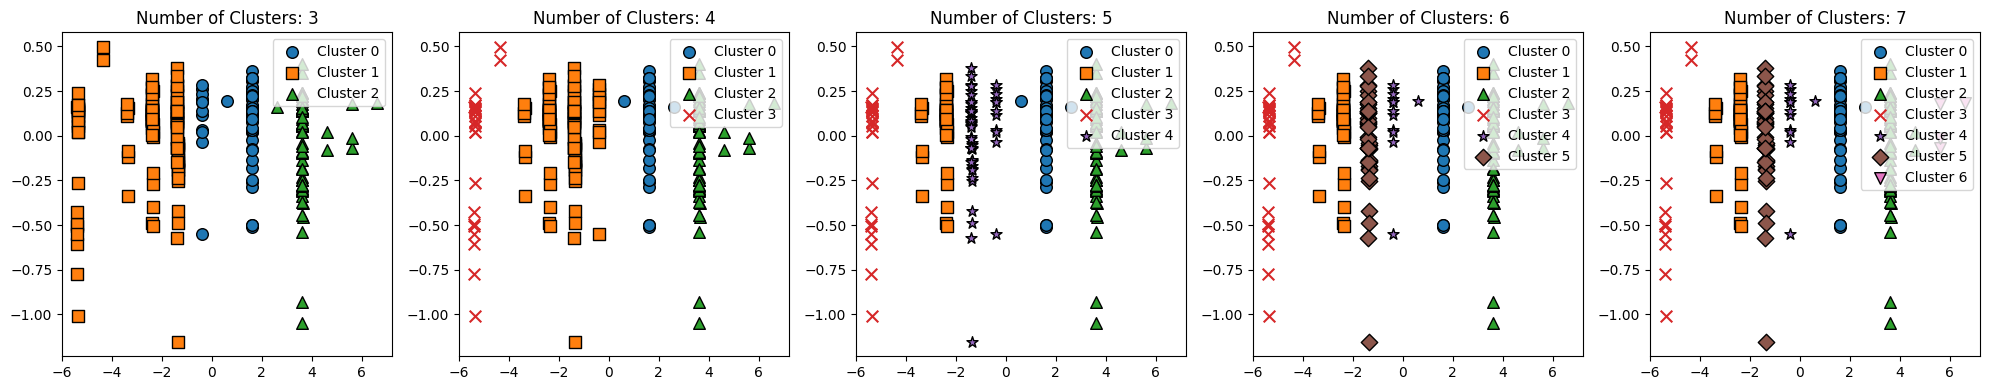

In [23]:
visualize_kmeans_plot_multi([3,4,5,6,7],df)

In [24]:
scaler = MinMaxScaler()
df['Brand_scaled'] = scaler.fit_transform(df[['Brand']])
df

,Price_log,Review_log,Rating,Discount,Brand,Brand_scaled
0,0.588854,0.739277,0.909091,0.122222,9,0.750000
1,0.619967,0.000000,0.000000,0.000000,0,0.000000
2,0.369893,0.760012,0.909091,0.000000,7,0.583333
3,0.452747,0.579363,0.818182,0.022222,7,0.583333
4,0.490896,0.590528,0.909091,0.333333,9,0.750000
...,...,...,...,...,...,...
224,0.377832,0.146325,0.818182,0.000000,7,0.583333
225,0.319155,0.205393,0.909091,0.555556,3,0.250000
226,0.450791,0.383951,0.909091,0.233333,7,0.583333
227,0.619967,0.310789,0.909091,0.033333,7,0.583333


/tmp/ipykernel_410/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_410/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_410/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_410/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is igno

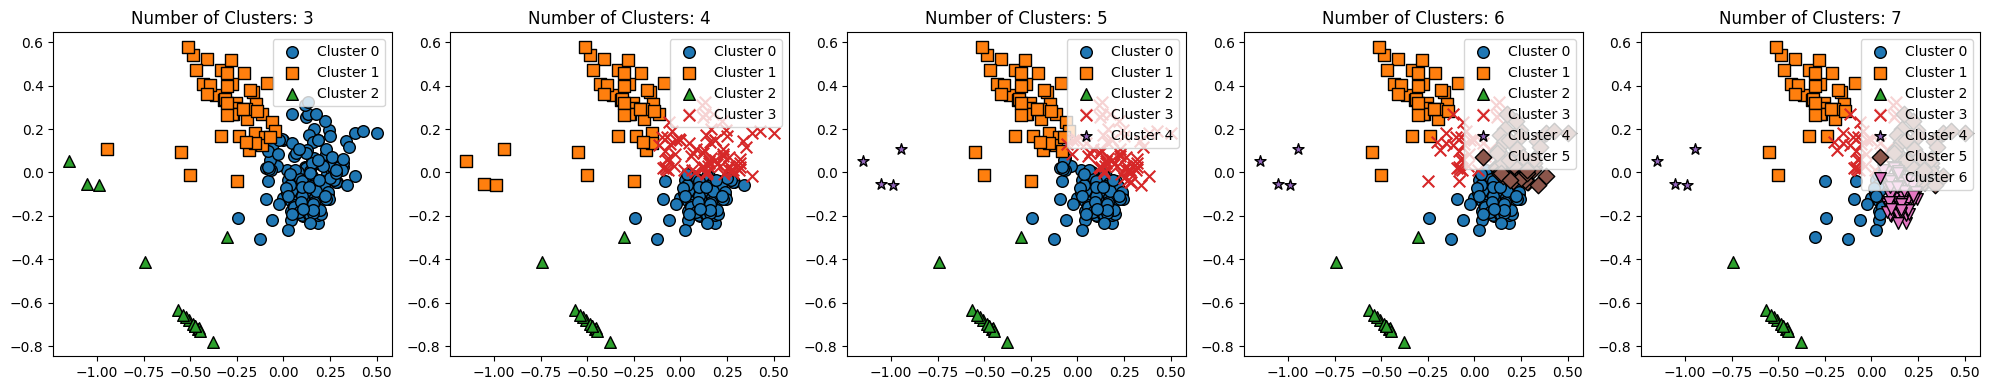

In [26]:
visualize_kmeans_plot_multi([3,4,5,6,7],df[['Price_log','Review_log','Rating','Discount']])

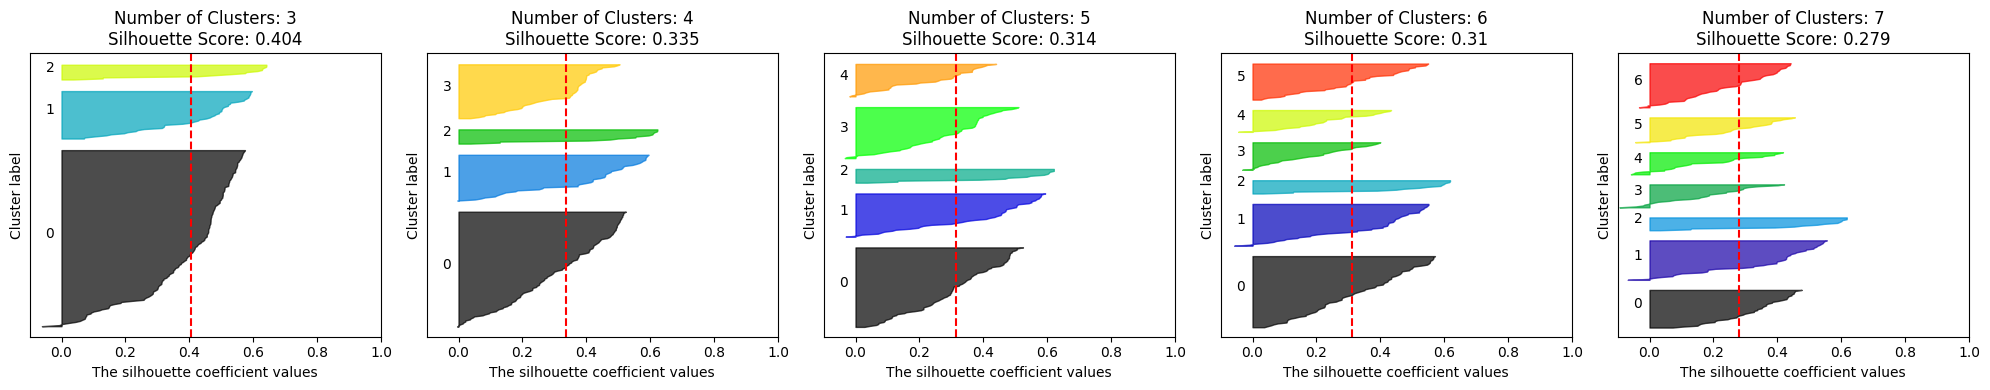

In [28]:
visualize_silhouette([3,4,5,6,7],df[['Price_log','Review_log','Rating','Discount']])

## 노트북 군집분석

In [29]:
df = df[['Price_log','Review_log','Rating','Discount']]

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

kmeans = KMeans(n_clusters= 5,random_state =0)
labels = kmeans.fit_predict(df)

df['Cluster'] = labels # 각 데이터가 어떤 군집에 속하는지
lap['Cluster'] = labels


/tmp/ipykernel_410/3124113526.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = labels


In [32]:
lap

,Product ID,Product Name,Price,Rating,Review Count,Discount,Stock,Brand,Price_log,Review_log,Cluster
0,4.692708e+09,삼성노트북 한컴오피스 증정 i7 윈도우11 가성비 사무용 대학생 인강용 광시야각 동...,1189000,5.0,1100,11,In Stock,삼성,13.988624,7.003974,3
1,8.116220e+09,에이수스 2024 TUF 게이밍 A15 라이젠7 라이젠 7000 시리즈 지포스 RT...,1349000,0.0,0,0,In Stock,ASUS,14.114875,0.000000,4
2,6.990470e+09,레노버 2022 아이디어패드 슬림 1 15AMN7 15.6 라이젠3 라이젠 7000...,488990,5.0,1339,0,In Stock,레노버,13.100099,7.200425,3
3,7.743817e+09,"레노버 2023 아이디어패드 슬림 3 15IAH8 코어i5 인텔 12세대, Arct...",684410,4.5,241,2,In Stock,레노버,13.436314,5.488938,3
4,7.991195e+09,"삼성전자 갤럭시북4 15.6 코어I5 13세대 한컴오피스팩 및 무선마우스, R-A5...",799000,5.0,268,30,In Stock,삼성,13.591117,5.594711,3
...,...,...,...,...,...,...,...,...,...,...,...
224,7.912802e+09,레노버 IdeaPad Slim1-15ALC7 + WIN11 사무용 인강용 노트북 R...,505000,4.5,3,0,In Stock,레노버,13.132316,1.386294,0
225,6.854946e+09,HP EliteBook X360 1030-G2 I5-7300U/8G/SSD256G/...,398000,5.0,6,50,In Stock,HP,12.894210,1.945910,2
226,6.052662e+09,"레노버 2021 ThinkPad L14 라이젠5 Pro 라이젠 5000 시리즈, B...",679000,5.0,37,21,In Stock,레노버,13.428378,3.637586,3
227,7.883088e+09,"레노버 2024 아이디어패드 5i 프로 14IMH 코어Ultra7, Arctic G...",1349000,5.0,18,3,In Stock,레노버,14.114875,2.944439,0


## 클러스터 통계 요약

In [33]:
lap_nums = lap.groupby('Cluster')[['Price',
                                   'Review Count',
                                   'Rating',
                                   'Discount']].agg({
                                                    'mean',
                                                    'median'
                                                   })
lap_nums

Price               Review Count             Rating            \
            median          mean       median        mean median      mean   
Cluster                                                                      
0         943470.0  1.014330e+06          5.0    9.097561    5.0  4.853659   
1         365950.0  3.449532e+05         21.0   47.852941    4.5  4.441176   
2         329000.0  3.504280e+05         17.0   41.866667    4.5  4.366667   
3        1079000.0  1.230105e+06        183.0  651.056604    5.0  4.886792   
4         909000.0  1.370766e+06          0.0    0.000000    0.0  0.000000   

        Discount             
          median       mean  
Cluster                      
0            4.0   8.756098  
1            0.0   5.000000  
2           50.0  52.088889  
3           11.0  13.320755  
4            0.0  18.933333

In [34]:
lap.groupby('Cluster')['Cluster'].count()

,Cluster
Cluster,
0,82
1,34
2,45
3,53
4,15


In [35]:
lap.groupby('Cluster')['Brand'].value_counts()

Cluster  Brand
0        레노버      22
         HP       21
         ASUS     11
         LG        9
         MSI       6
         삼성        5
         DELL      4
         에이서       3
         기가바이트     1
1        삼성       12
         LG        6
         레노버       5
         HP        4
         ASUS      2
         아이뮤즈      2
         DELL      1
         빅트랙       1
         주연테크      1
2        삼성       21
         LG       15
         HP        4
         레노버       3
         DELL      2
3        삼성       14
         레노버      13
         LG       12
         MSI       5
         HP        4
         ASUS      3
         Apple     2
4        ASUS      7
         레노버       3
         LG        2
         HP        1
         MSI       1
         삼성        1
Name: count, dtype: int64

In [39]:
# [한글폰트 설치 - Colab]
import pandas as pd
import numpy as np

# Install Korean font
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Configure Matplotlib to use NanumGothic
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # To prevent breaking minus sign

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 5 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (9,542 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direc

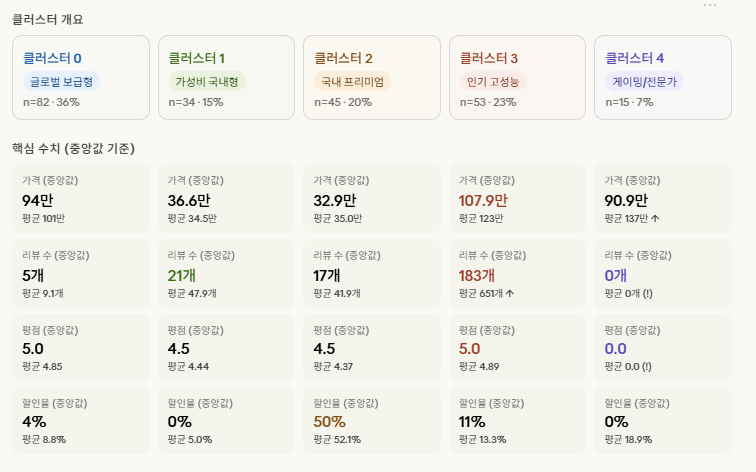

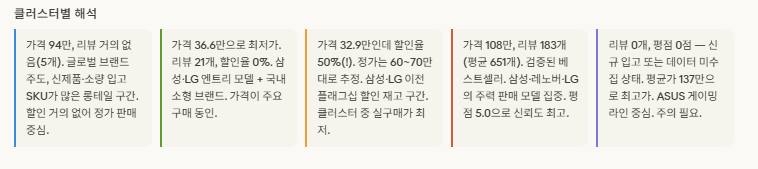

# 노트북 클러스터 분석

## Cluster 0 — 글로벌 보급형 (n=82, 36%)

- **주요 브랜드**: 레노버(22), HP(21), ASUS(11), LG(9)
- **가격**: 중앙값 943,470원 / 평균 1,014,330원
- **리뷰 수**: 중앙값 5개 / 평균 9.1개
- **평점**: 중앙값 5.0 / 평균 4.85
- **할인율**: 중앙값 4% / 평균 8.8%
- **특징**: 글로벌 브랜드 중심의 중고가 제품군. 리뷰가 거의 없어 신규 입고·소량 유통 SKU가 다수. 정가 판매 위주의 롱테일 구간.

---

## Cluster 1 — 가성비 국내형 (n=34, 15%)

- **주요 브랜드**: 삼성(12), LG(6), 레노버(5), HP(4)
- **가격**: 중앙값 365,950원 / 평균 344,953원
- **리뷰 수**: 중앙값 21개 / 평균 47.9개
- **평점**: 중앙값 4.5 / 평균 4.44
- **할인율**: 중앙값 0% / 평균 5.0%
- **특징**: 5개 클러스터 중 최저가. 삼성 엔트리 모델이 주도하며 아이뮤즈·빅트랙 등 국내 소규모 브랜드 포함. 이미 낮은 가격이 실구매가이며, 가격 민감 소비자 및 B2B·교육시장 중심 세그먼트.

---

## Cluster 2 — 할인 재고 특가형 (n=45, 20%)

- **주요 브랜드**: 삼성(21), LG(15), HP(4), 레노버(3)
- **가격**: 중앙값 329,000원 / 평균 350,428원
- **리뷰 수**: 중앙값 17개 / 평균 41.9개
- **평점**: 중앙값 4.5 / 평균 4.37
- **할인율**: 중앙값 50% / 평균 52.1%
- **특징**: 가격은 낮지만 할인율이 50%로 전체 최고. 정가 기준 65~70만원대 제품이 반값에 유통되는 구간으로, 삼성·LG 이전 세대 플래그십 재고가 주력. 스펙 대비 실구매가 효율이 높은 집단.

---

## Cluster 3 — 인기 고성능 베스트셀러 (n=53, 23%)

- **주요 브랜드**: 삼성(14), 레노버(13), LG(12), MSI(5), Apple(2)
- **가격**: 중앙값 1,079,000원 / 평균 1,230,105원
- **리뷰 수**: 중앙값 183개 / 평균 651개
- **평점**: 중앙값 5.0 / 평균 4.89
- **할인율**: 중앙값 11% / 평균 13.3%
- **특징**: 리뷰 평균 651개로 타 클러스터와 압도적 차이. 소비자 검증이 완료된 시장 주력 베스트셀러 집단. 삼성·레노버·LG가 고르게 분포해 브랜드 쏠림 없이 전반적인 인기 모델이 경쟁 중. 신뢰도와 판매량 모두 높은 핵심 세그먼트.

---

## Cluster 4 — 게이밍/전문가형 (n=15, 7%) ⚠️

- **주요 브랜드**: ASUS(7), 레노버(3), LG(2), MSI(1)
- **가격**: 중앙값 909,000원 / 평균 1,370,766원
- **리뷰 수**: 중앙값 0개 / 평균 0개
- **평점**: 중앙값 0.0 / 평균 0.0
- **할인율**: 중앙값 0% / 평균 18.9%
- **특징**: 리뷰·평점이 전부 0으로 데이터 미수집 상태. 신규 입고 또는 플랫폼 리뷰 미연동 상품으로 추정. ASUS 게이밍 라인 중심이며 평균가 137만원으로 전체 최고가. 클러스터링 전 결측치 처리 후 재분석 권장.

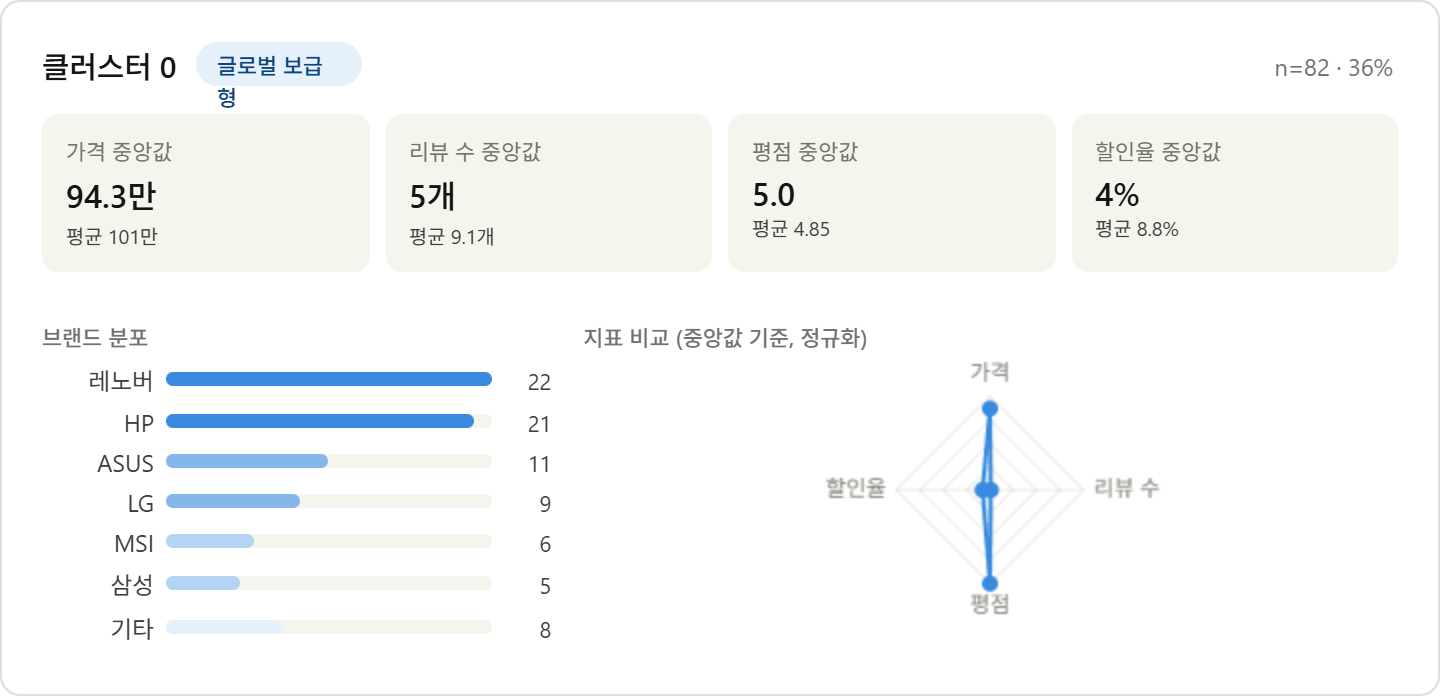

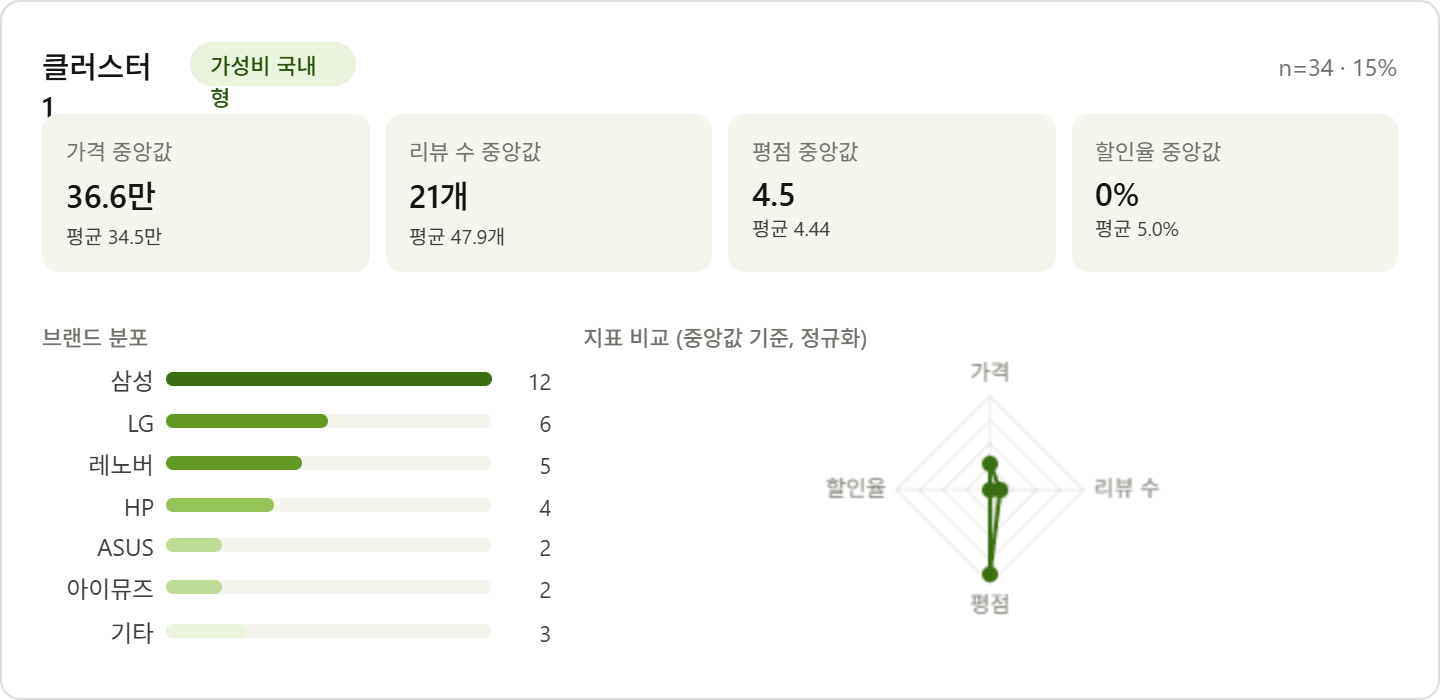

- 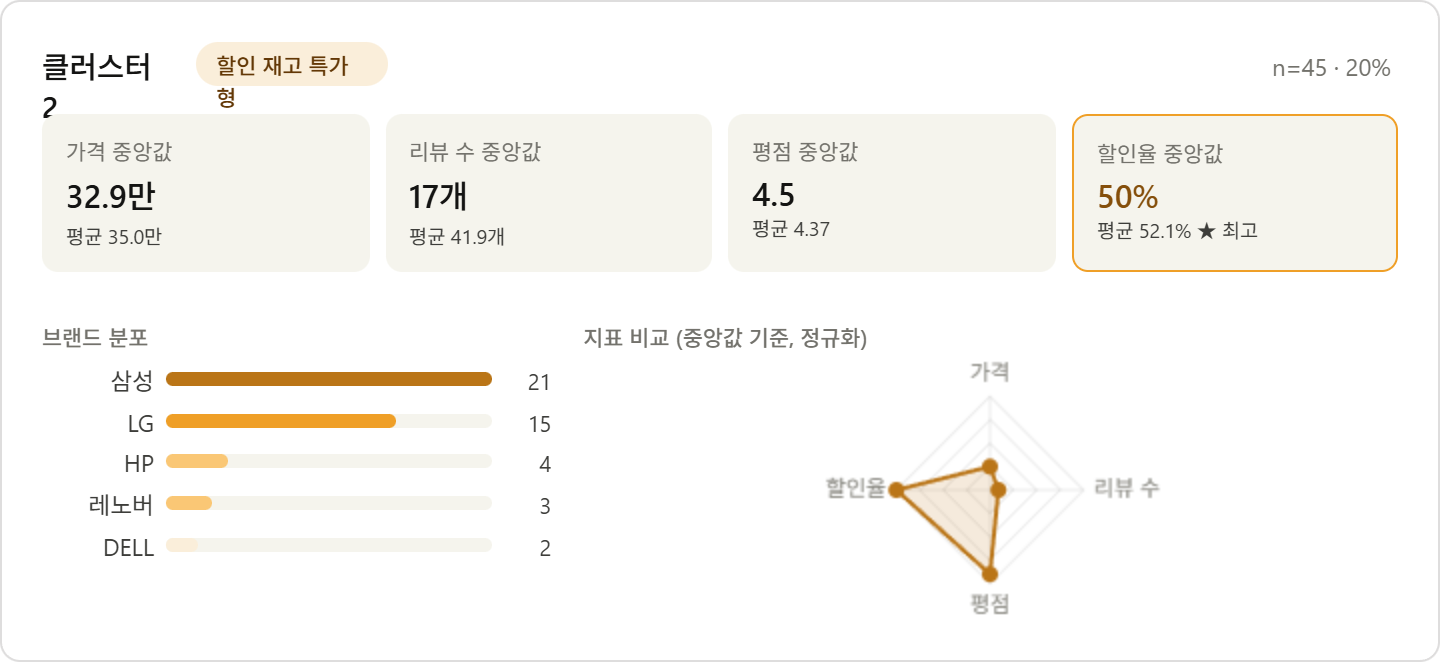

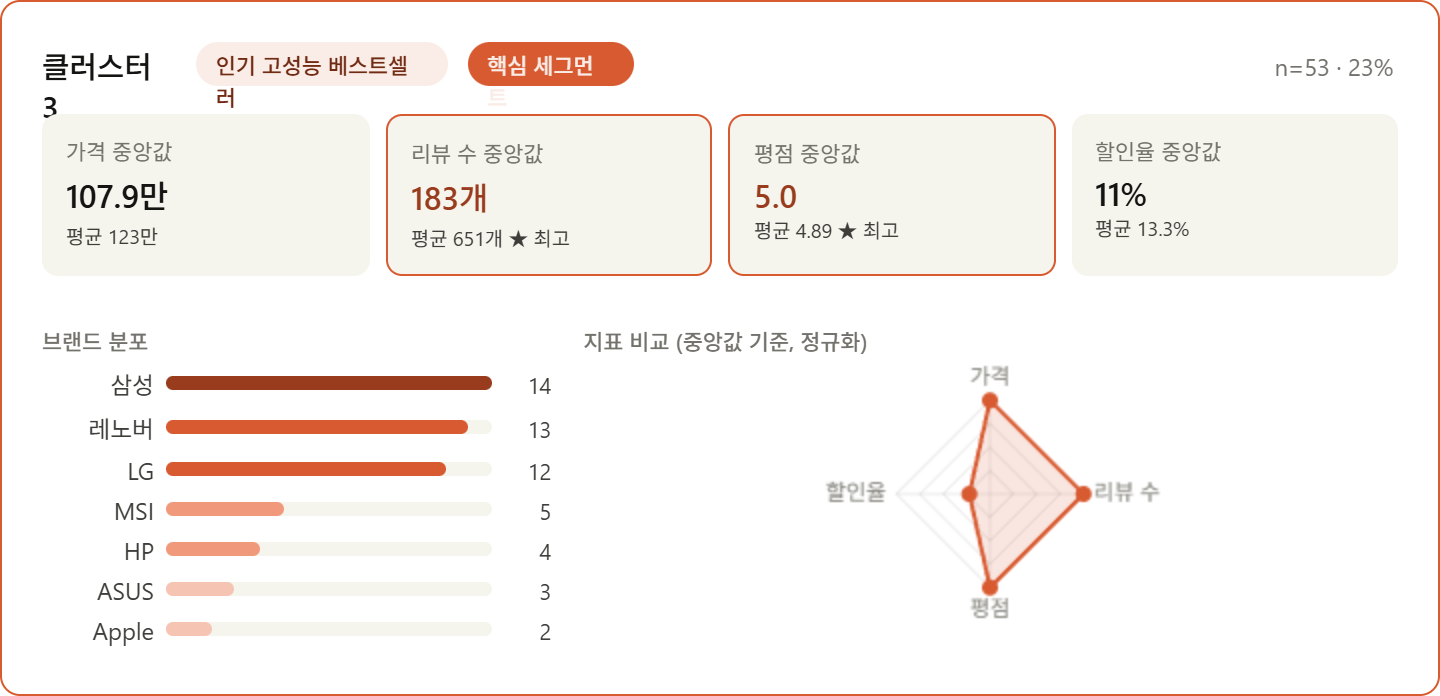

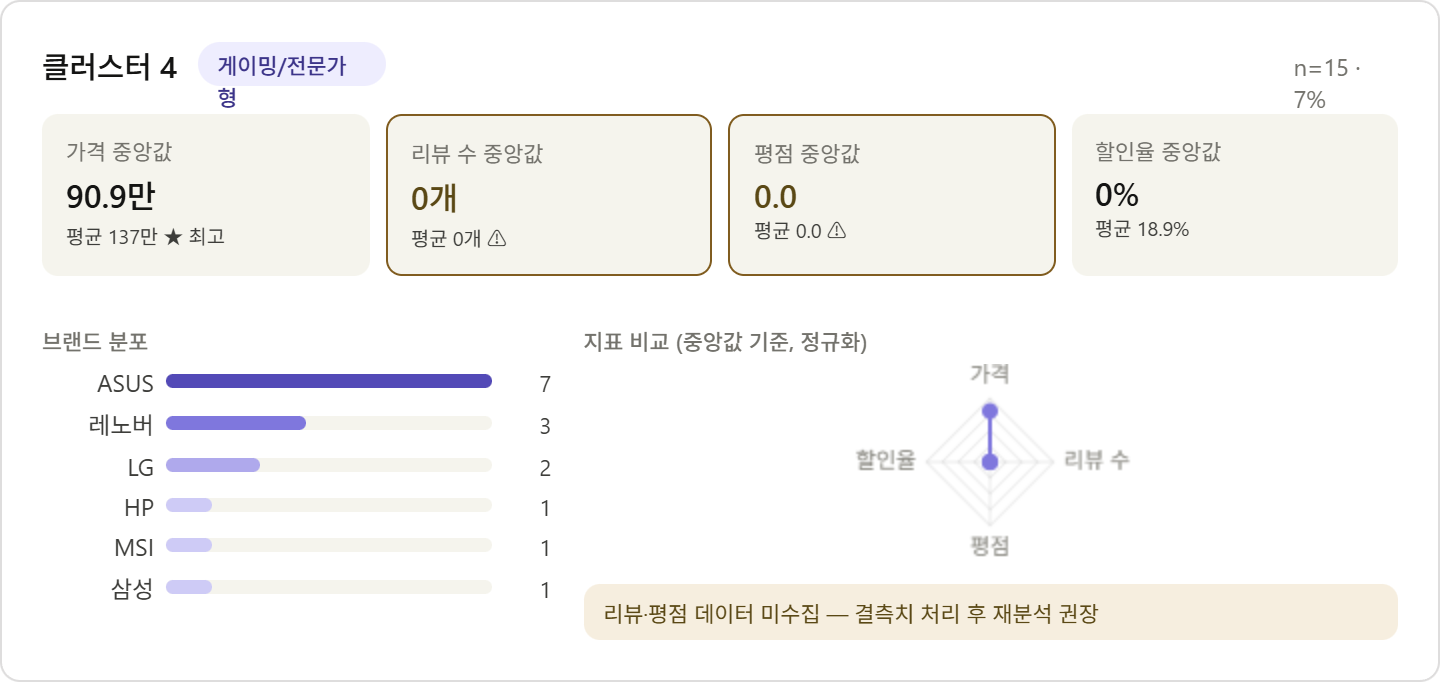

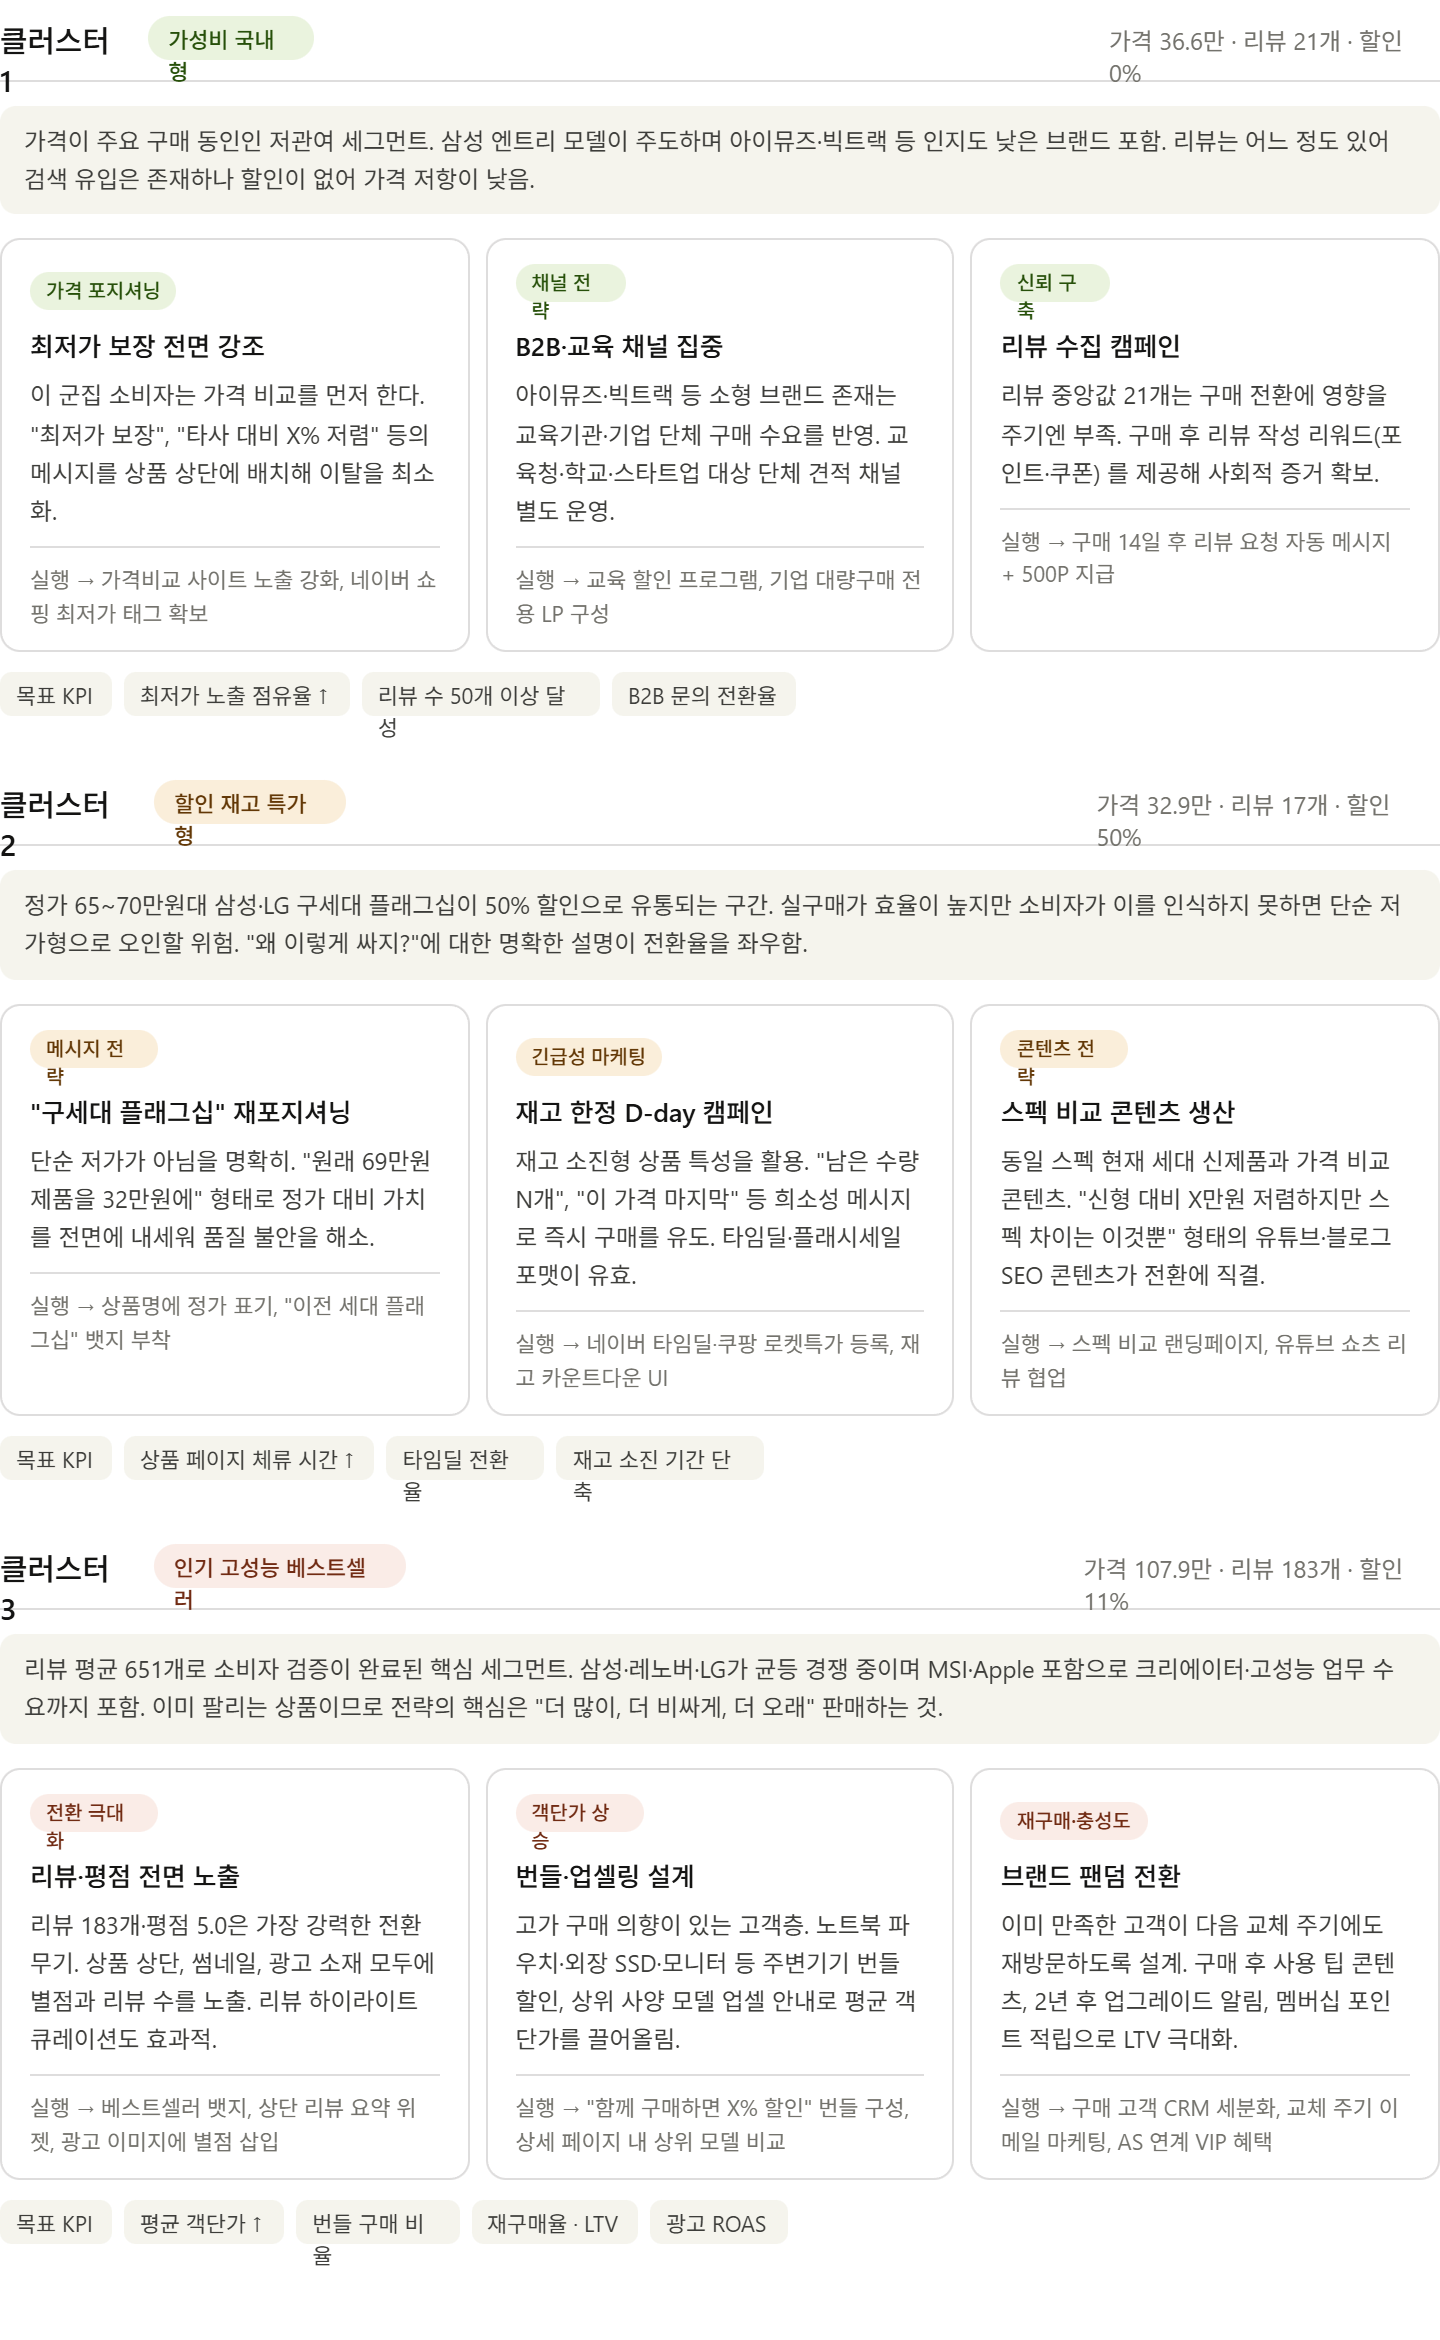

- 클러스터 1은 **가격이 유일한 무기**인 만큼 최저가 노출 점유율을 지키는 것이 최우선이고, 리뷰 21개는 신뢰 형성에 아직 부족하니 **리뷰 수집이 단기 과제**입니다. **B2B·교육 채널**은 이 군집에서만 보이는 소규모 브랜드들의 존재로 유추할 수 있는 숨은 수요입니다.
- 클러스터 2는 **할인율 50%라는 수치**가 마케팅 자산인데, 이를 제대로 활용하지 않으면 소비자가 품질을 의심하거나 단순 저가로 오인합니다. **"정가 대비 가치"를 명확히 전달하는 것이 핵심**이고, 재고 소진형 특성상 긴급성 메시지가 전환에 직결됩니다.
- 클러스터 3은 이미 팔리는 제품들이기 때문에 **신규 전환보다 객단가 상승과 재구매율**이 전략의 중심이 됩니다. 리뷰·평점이라는 검증된 자산을 모든 광고 소재에 적극 활용하는 것이 ROI가 가장 높습니다.